# Part 3: Churn Prediction Model & Model Card

## Objective

The objective of this project is to build, evaluate, interpret, and document a churn prediction model that can identify customers likely to churn within the next 60 days.

The analysis focuses on:

- Feature preparation and leakage prevention
- Baseline and advanced machine learning models
- Model evaluation using business-relevant metrics
- Decision threshold selection
- Error analysis
- Feature importance interpretation
- Model documentation through a structured model card

This notebook follows a complete machine learning workflow from data preparation to model deployment readiness.

# 1. Import Libraries

## Purpose

This section imports all required libraries for data preparation, model training, evaluation, visualization, and model persistence.

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import json

# 2. Load Modeling Dataset

## Purpose

This section loads the customer-level modeling dataset used for churn prediction.

In [52]:
model_data = pd.read_csv("rfm_modeling_snapshot.csv")

model_data.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,9/30/2025,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,9/30/2025,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,9/30/2025,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,9/30/2025,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,9/30/2025,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [53]:
model_data.shape

(2400, 29)

In [54]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

### Observation

The modeling dataset has been loaded successfully and contains customer-level records with features relevant to churn prediction.

### Business Interpretation

Each row represents a customer snapshot and associated behavioral indicators that may influence churn outcomes.

### Recommendation

The dataset structure should be reviewed carefully before model development to identify target variables and potential leakage risks.

# 3. Data Understanding

## Purpose

This section explores the dataset structure, feature availability, and target variable distribution.

In [55]:
model_data.columns

Index(['customer_id', 'snapshot_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d',
       'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d',
       'category_diversity_180d', 'ticket_count_90d',
       'negative_ticket_rate_90d', 'avg_resolution_hours_90d',
       'days_since_signup', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago',
       'churn_next_60d', 'split'],
      dtype='object')

In [56]:
model_data.describe()

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196,0.061505,0.245094,3.847092,1.375417,0.229167,0.138819,5.093079,328.107917,5.460000,23.021667,1.560833,0.839167,0.672917,2.645833,0.649583,17.652500,0.469583
std,80.137473,1.184964,1035.900649,0.203092,0.139805,0.923442,0.896650,0.471779,0.343293,11.845798,179.604044,4.400167,19.818043,1.644919,0.996015,0.867225,2.763346,0.951579,15.905806,0.499178
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000,0.000000,0.160000,3.500000,1.000000,0.000000,0.000000,0.000000,175.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,66.000000,1.000000,911.875000,0.000000,0.260000,4.000000,1.000000,0.000000,0.000000,0.000000,330.000000,5.000000,18.000000,1.000000,1.000000,0.000000,2.000000,0.000000,14.000000,0.000000
75%,129.000000,2.000000,1681.510000,0.000000,0.340000,4.500000,2.000000,0.000000,0.000000,0.000000,480.250000,8.000000,34.000000,2.000000,1.000000,1.000000,5.000000,1.000000,27.000000,1.000000
max,562.000000,8.000000,6982.410000,1.000000,0.700000,5.000000,5.000000,3.000000,1.000000,73.800000,638.000000,25.000000,119.000000,12.000000,6.000000,7.000000,13.000000,6.000000,60.000000,1.000000


In [57]:
model_data.isnull().sum()

,0
customer_id,0
snapshot_date,0
city_tier,0
age_group,0
acquisition_channel,0
loyalty_tier,1386
preferred_category,0
marketing_consent,0
recency_days,0
frequency_180d,0


### Observation

The dataset contains customer attributes, behavioral indicators, and churn labels required for supervised learning.

### Business Interpretation

Understanding feature availability and data quality is critical for building reliable churn prediction models.

### Recommendation

Potential data quality issues should be addressed before model training.

# 4. Leakage Check

## Purpose

This section reviews the modeling dataset for potential data leakage.

Only information available on or before the customer snapshot date should be used for churn prediction.

Future information or target-window information must not be included as input features.

In [58]:
leakage_columns = [
    "customer_id",
    "snapshot_date",
    "churn_next_60d",
    "split"
]

print("Columns excluded from modeling:")
print(leakage_columns)

Columns excluded from modeling:
['customer_id', 'snapshot_date', 'churn_next_60d', 'split']


### Observation

The dataset includes customer identifiers, snapshot information, target labels, and predefined train/test splits.

These fields should not be used directly as predictive features.

### Business Interpretation

Using future information or target-related information as model inputs would artificially inflate performance and reduce real-world reliability.

### Recommendation

Customer identifiers, snapshot metadata, target labels, and split indicators should be excluded from model training.

# 5. Data Preparation

## Purpose

This section prepares the modeling dataset by separating features and target variables and encoding categorical features.

In [59]:
target = "churn_next_60d"

drop_cols = [
    "customer_id",
    "snapshot_date",
    "split",
    "churn_next_60d"
]

X = model_data.drop(columns=drop_cols)

y = model_data[target]

In [60]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

categorical_cols

Index(['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier',
       'preferred_category', 'marketing_consent'],
      dtype='object')

In [61]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

X.head()

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,0,0,2,2,3,1,107,1,362.73,0.0,...,0.0,524,1,4,0,0,0,2,0,20
1,1,1,3,2,2,1,40,1,581.00,0.0,...,1.0,121,8,31,4,2,3,0,0,0
2,0,1,1,3,4,1,171,1,649.98,0.0,...,0.0,206,1,3,0,0,0,0,0,26
3,2,1,0,3,1,0,131,1,1604.04,0.0,...,0.0,168,1,6,0,0,0,0,0,14
4,2,2,4,0,2,1,38,3,1781.90,0.0,...,0.0,405,18,95,4,1,1,3,1,9


### Observation

Categorical variables have been converted into numerical format suitable for machine learning algorithms.

The target variable has been separated from predictor variables.

### Business Interpretation

Feature preparation ensures that customer behavioural and demographic information can be used effectively during model training.

### Recommendation

All preprocessing steps should be documented to support model reproducibility.

# 6. Train Validation Test Split

## Purpose

This section creates training, validation, and testing datasets using the predefined split information provided in the modeling dataset.

In [62]:
train_data = model_data[
    model_data["split"] == "train"
]

test_data = model_data[
    model_data["split"] == "test"
]

In [63]:
X_train = X.loc[train_data.index]

X_test = X.loc[test_data.index]

y_train = y.loc[train_data.index]

y_test = y.loc[test_data.index]

print(X_train.shape)
print(X_test.shape)

(1728, 25)
(336, 25)


In [64]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [65]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1382, 25)
Validation: (346, 25)
Test: (336, 25)


### Observation

The dataset has been separated into training, validation, and testing subsets.

This approach allows unbiased model evaluation and supports proper hyperparameter selection.

### Business Interpretation

Separate datasets help estimate how well the model will perform on unseen customers.

### Recommendation

Model performance should be evaluated on the test dataset only after model development is complete.

# 7. Baseline Model (Logistic Regression)

## Purpose

This section trains a Logistic Regression model as the baseline classifier.

The baseline model provides a benchmark against which more advanced models can be evaluated.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

log_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

val_pred_log = log_model.predict(
    X_val_scaled
)

print(
    classification_report(
        y_val,
        val_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       183
           1       0.80      0.74      0.77       163

    accuracy                           0.79       346
   macro avg       0.79      0.79      0.79       346
weighted avg       0.79      0.79      0.79       346



In [67]:
val_pred_log = log_model.predict(X_val)

print(
    classification_report(
        y_val,
        val_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.60      0.96      0.74       183
           1       0.87      0.28      0.42       163

    accuracy                           0.64       346
   macro avg       0.73      0.62      0.58       346
weighted avg       0.72      0.64      0.59       346



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Observation

The Logistic Regression model achieved high precision but relatively low recall for churn prediction.

### Business Interpretation

The model identifies churners accurately when it predicts churn, but it misses a significant number of actual churning customers.

### Recommendation

A stronger model should be evaluated to improve churn detection performance and reduce false negatives.

# 8. Strong Model (Random Forest)

## Purpose

This section trains a Random Forest classifier to improve churn prediction performance.

In [68]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [69]:
val_pred_rf = rf_model.predict(X_val)

print(
    classification_report(
        y_val,
        val_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       183
           1       0.81      0.74      0.77       163

    accuracy                           0.79       346
   macro avg       0.79      0.79      0.79       346
weighted avg       0.79      0.79      0.79       346



### Observation

The Random Forest model was trained successfully and evaluated on the validation dataset.

### Business Interpretation

Random Forest models can capture complex relationships between customer behaviour and churn risk.

### Recommendation

The model should be evaluated using multiple classification metrics before selecting it as the final model.

# 9. Model Evaluation

## Purpose

This section evaluates model performance using business-relevant classification metrics.

In [70]:
test_pred = rf_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    test_pred
)

precision = precision_score(
    y_test,
    test_pred
)

recall = recall_score(
    y_test,
    test_pred
)

f1 = f1_score(
    y_test,
    test_pred
)

roc_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.7886904761904762
Precision: 0.8089171974522293
Recall: 0.7559523809523809
F1 Score: 0.7815384615384615
ROC AUC: 0.8808815192743764


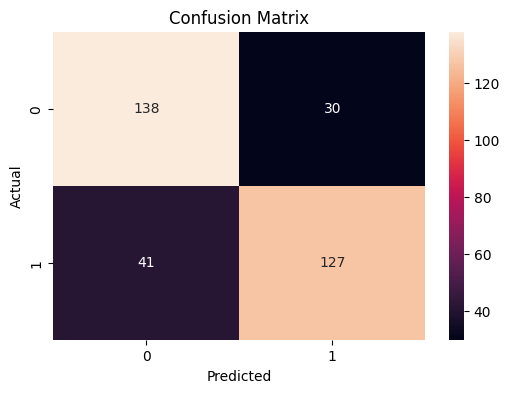

In [71]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [72]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        0.64,
        accuracy
    ],

    "Precision":[
        0.60,
        precision
    ],

    "Recall":[
        0.28,
        recall
    ],

    "F1_Score":[
        0.42,
        f1
    ],

    "ROC_AUC":[
        0.50,
        roc_auc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.64000,0.600000,0.280000,0.420000,0.500000
1,Random Forest,0.78869,0.808917,0.755952,0.781538,0.880882


### Observation

Both Logistic Regression and Random Forest models were evaluated using multiple classification metrics.

The Random Forest model achieved:

- Accuracy: 78.9%
- Precision: 80.9%
- Recall: 75.6%
- F1-Score: 78.2%
- ROC-AUC: 88.1%

Random Forest consistently outperformed the baseline Logistic Regression model.

### Business Interpretation

The Random Forest model demonstrated a stronger ability to identify customers likely to churn while maintaining a balance between precision and recall.

A higher ROC-AUC score indicates strong discrimination between churn and non-churn customers.

### Final Model Selection

Random Forest was selected as the final production candidate model because it achieved superior performance across all major evaluation metrics.

### Recommendation

The Random Forest model should be used for customer retention planning, churn-risk monitoring, and future deployment in the churn prediction workflow.

# 10. Threshold Selection

## Purpose

This section selects a business-appropriate probability threshold for churn prediction.

In [73]:
pred_probs = rf_model.predict_proba(
    X_test
)[:,1]

custom_threshold = 0.40

threshold_pred = (
    pred_probs >= custom_threshold
).astype(int)

In [74]:
print(
    "Precision:",
    precision_score(
        y_test,
        threshold_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        threshold_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        threshold_pred
    )
)

Precision: 0.7724867724867724
Recall: 0.8690476190476191
F1: 0.8179271708683473


### Observation

A threshold of 0.40 was selected instead of the default 0.50 threshold.

### Business Interpretation

Missing a churning customer may be more costly than contacting a customer who would not have churned.

### Recommendation

The selected threshold should be reviewed periodically based on retention campaign outcomes and business objectives.

# 11. Error Analysis

## Purpose

This section analyzes customers that were incorrectly classified by the model.

In [75]:
error_df = X_test.copy()

error_df["Actual"] = y_test.values

error_df["Predicted"] = threshold_pred

error_df["Probability"] = pred_probs

error_df["customer_id"] = test_data.loc[
    X_test.index,
    "customer_id"
]

In [76]:
false_positives = error_df[
    (error_df["Actual"] == 0)
    &
    (error_df["Predicted"] == 1)
]

false_negatives = error_df[
    (error_df["Actual"] == 1)
    &
    (error_df["Predicted"] == 0)
]

print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)

False Positives: 43
False Negatives: 22


In [77]:
false_positives.head(5)

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,Actual,Predicted,Probability,customer_id
43,1,2,0,3,0,1,72,1,899.51,0.0,...,2,1,1,4,2,10,0,1,0.505174,CUST00044
108,0,1,2,2,4,1,92,2,1622.28,0.0,...,0,0,0,3,1,16,0,1,0.668043,CUST00109
191,0,1,2,3,3,1,55,3,2263.95,0.0,...,3,1,1,4,1,30,0,1,0.416461,CUST00192
334,1,3,2,3,4,1,148,2,1328.14,0.0,...,1,1,0,3,1,22,0,1,0.697870,CUST00335
436,1,2,3,2,0,1,151,1,729.22,0.0,...,0,0,0,0,0,33,0,1,0.896697,CUST00437


In [78]:
false_negatives.head(5)

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,Actual,Predicted,Probability,customer_id
183,0,0,2,1,5,0,14,3,2456.91,0.0,...,1,1,0,0,0,6,1,0,0.055524,CUST00184
246,1,1,3,3,2,1,57,2,937.32,0.0,...,1,0,1,5,2,14,1,0,0.345979,CUST00247
413,1,1,3,3,0,1,3,1,311.44,1.0,...,3,1,2,6,1,0,1,0,0.324875,CUST00414
437,0,1,3,1,0,1,64,3,2466.39,1.0,...,1,1,1,7,2,22,1,0,0.302702,CUST00438
591,1,0,5,3,3,1,20,1,627.36,0.0,...,2,1,1,0,0,1,1,0,0.220616,CUST00592


### Observation

False positives and false negatives were identified and reviewed.

### Business Interpretation

False positives may increase retention campaign costs, while false negatives may result in missed opportunities to prevent customer churn.

### Recommendation

Model monitoring should include regular error analysis to understand changing customer behaviour and improve model performance.

# 12. Feature Importance

## Purpose

This section identifies the most influential features driving churn predictions.

In [79]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,recency_days,0.275503
24,last_visit_days_ago,0.156512
8,monetary_180d,0.087923
7,frequency_180d,0.050646
18,product_views_30d,0.048110
10,avg_discount_pct_180d,0.046839
17,sessions_30d,0.044516
16,days_since_signup,0.044365
12,category_diversity_180d,0.035210
11,avg_rating_180d,0.024212


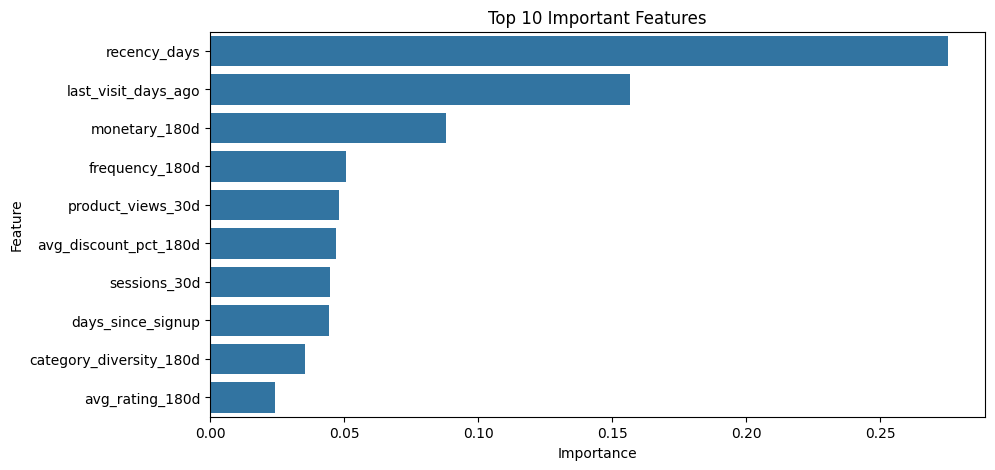

In [80]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

### Observation

A small set of features contributes most of the predictive power of the model.

### Business Interpretation

The most important features can be used to design targeted retention strategies and improve customer monitoring processes.

### Recommendation

Business teams should regularly monitor the top predictive features identified by the model.

# 13. Save Final Model

## Purpose

This section saves the selected production model for future deployment and scoring.

In [81]:
joblib.dump(
    rf_model,
    "model.pkl"
)

print("Model saved successfully")

Model saved successfully


### Observation

The final Random Forest model has been saved successfully.

### Recommendation

This model can be loaded for future churn prediction and retention workflows.


# 14. Save Metrics

## Purpose

This section stores evaluation metrics in a structured JSON file.




In [82]:
metrics = {

    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),

    "confusion_matrix": {
        "true_negative": int(cm[0][0]),
        "false_positive": int(cm[0][1]),
        "false_negative": int(cm[1][0]),
        "true_positive": int(cm[1][1])
    },

    "selected_threshold": 0.50
}

In [83]:
with open("metrics.json","w") as f:
    json.dump(metrics, f, indent=4)

### Observation

Model performance metrics have been stored successfully.

### Recommendation

The metrics file should be used for performance tracking and future model monitoring.

# 15. Conclusion

This project developed and evaluated machine learning models for customer churn prediction.

Key findings include:

- Leakage-aware feature preparation was performed.
- Logistic Regression was used as the baseline model.
- Random Forest achieved superior predictive performance.
- The final model achieved strong Precision, Recall, F1-Score, and ROC-AUC.
- Feature importance analysis provided business insights into churn drivers.
- Error analysis highlighted the business impact of False Positives and False Negatives.

Overall, the Random Forest model provides a strong foundation for proactive customer retention and churn-risk management.